# Insurance Claim Approval Prediction
---
## Project Objective

Predict whether an **insurance claim will be Approved (A) or Denied (D)** using transactional insurance data merged with employee (agent) and vendor details.  
This is a **binary classification** problem with real-world business impact  helping insurance companies streamline claim processing and detect potentially fraudulent or invalid claims.

## Dataset Overview


 **Target Variable:** `CLAIM_STATUS` - `A` = Approved, `D` = Denied  



## Data Gathering <a id='0'></a>

### About the Datasets

This project uses **three relational CSV datasets** from an insurance company's operational database, which are merged together to form the modelling dataset.

| Property | Details |
|---|---|
| Source | Insurance Company Operational Database (3 CSV files) |
| Main Table | `insurance_data.csv` - 10,000 transactions |
| Lookup Table 1 | `employee_data.csv` - 1,200 agents |
| Lookup Table 2 | `vendor_data.csv` - 600 vendors |
| Target | `CLAIM_STATUS` (A = Approved / D = Denied) |
| Task | Binary Classification |
| Class Balance | ~95% Approved, ~5% Denied (Highly Imbalanced) |

### Feature Categories (Insurance Data)
- **Transaction Info:** TXN_DATE_TIME, TRANSACTION_ID, POLICY_NUMBER, INSURANCE_TYPE
- **Customer Demographics:** AGE, MARITAL_STATUS, EMPLOYMENT_STATUS, SOCIAL_CLASS, EDUCATION
- **Financial:** PREMIUM_AMOUNT, CLAIM_AMOUNT, ROUTING_NUMBER, ACCT_NUMBER
- **Risk Profile:** RISK_SEGMENTATION, HOUSE_TYPE, NO_OF_FAMILY_MEMBERS, TENURE
- **Incident Details:** INCIDENT_SEVERITY, AUTHORITY_CONTACTED, ANY_INJURY, POLICE_REPORT_AVAILABLE
- **Target:** `CLAIM_STATUS` Whether the claim was Approved or Denied

### Data Collection Method
The three CSV files are joined using foreign keys:
- `insurance_data.AGENT_ID` - `employee_data.AGENT_ID`
- `insurance_data.VENDOR_ID` - `vendor_data.VENDOR_ID`

## Step 1 Data Loading <a id='1'></a>

In [1]:
#  Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn — preprocessing & utilities
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer

# Sklearn — models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

# Sklearn — metrics
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve, f1_score, precision_score, recall_score,
    ConfusionMatrixDisplay)

# Imbalance handling
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

# Plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
COLORS = ['Green', 'Red']

print(" All libraries imported successfully!")

 All libraries imported successfully!


In [2]:
#  Load the Three Datasets
df_insurance = pd.read_csv('insurance_data.csv')
df_employee  = pd.read_csv('employee_data.csv')
df_vendor    = pd.read_csv('vendor_data.csv')

print(" Dataset Shapes:")
print(f" Insurance: {df_insurance.shape[0]:>6,} rows × {df_insurance.shape[1]:>2} columns")
print(f" Employee: {df_employee.shape[0]:>6,} rows × {df_employee.shape[1]:>2} columns")
print(f" Vendor: {df_vendor.shape[0]:>6,} rows × {df_vendor.shape[1]:>2} columns")

 Dataset Shapes:
 Insurance: 10,000 rows × 38 columns
 Employee:  1,200 rows × 10 columns
 Vendor:    600 rows ×  7 columns


In [3]:
datasets = {"Insurance": df_insurance, "Employee": df_employee, "Vendor": df_vendor}

print("Dataset Shapes:")
for name, df in datasets.items():
    print(f"{name}: {df.shape[0]:,} rows × {df.shape[1]} columns")
    

Dataset Shapes:
Insurance: 10,000 rows × 38 columns
Employee: 1,200 rows × 10 columns
Vendor: 600 rows × 7 columns


In [4]:
# Preview each dataset
print("Insurance Data")
display(df_insurance.head())

print("\nEmployee Data")
display(df_employee.head())

print("\nVendor Data")
display(df_vendor.head())

Insurance Data


,TXN_DATE_TIME,TRANSACTION_ID,CUSTOMER_ID,POLICY_NUMBER,POLICY_EFF_DT,LOSS_DT,REPORT_DT,INSURANCE_TYPE,PREMIUM_AMOUNT,CLAIM_AMOUNT,...,CLAIM_STATUS,INCIDENT_SEVERITY,AUTHORITY_CONTACTED,ANY_INJURY,POLICE_REPORT_AVAILABLE,INCIDENT_STATE,INCIDENT_CITY,INCIDENT_HOUR_OF_THE_DAY,AGENT_ID,VENDOR_ID
0,2020-06-01 00:00:00,TXN00000001,A00003822,PLC00008468,2015-06-23,2020-05-16,2020-05-21,Health,157.13,9000,...,A,Major Loss,Police,0,1,GA,Savannah,4,AGENT00413,VNDR00556
1,2020-06-01 00:00:00,TXN00000002,A00008149,PLC00009594,2018-04-21,2020-05-13,2020-05-18,Property,141.71,26000,...,A,Total Loss,Ambulance,1,0,AL,Montgomery,0,AGENT00769,VNDR00592
2,2020-06-01 00:00:00,TXN00000003,A00003172,PLC00007969,2019-10-03,2020-05-21,2020-05-26,Property,157.24,13000,...,A,Total Loss,Police,0,1,CO,Grand Junction,19,AGENT00883,VNDR00031
3,2020-06-01 00:00:00,TXN00000004,A00007572,PLC00009292,2016-11-29,2020-05-14,2020-05-19,Health,172.87,16000,...,A,Minor Loss,Ambulance,0,0,GA,Savannah,12,AGENT00278,VNDR00075
4,2020-06-01 00:00:00,TXN00000005,A00008173,PLC00000204,2011-12-26,2020-05-17,2020-05-22,Travel,88.53,3000,...,A,Major Loss,Police,0,1,TN,Nashville,18,AGENT00636,VNDR00472



Employee Data


,AGENT_ID,AGENT_NAME,DATE_OF_JOINING,ADDRESS_LINE1,ADDRESS_LINE2,CITY,STATE,POSTAL_CODE,EMP_ROUTING_NUMBER,EMP_ACCT_NUMBER
0,AGENT00001,Ray Johns,1993-06-05,1402 Maggies Way,NaN,Waterbury Center,VT,5677,34584958,HKUN51252328472585
1,AGENT00002,Angelo Borjon,2005-12-27,414 Tanya Pass,NaN,Panama City,FL,32404,107363763,OPIS19290040088204
2,AGENT00003,Candy Spellman,2003-09-02,606 National Street,#306,Fayetteville,AR,72701,81744097,YSCJ67489688482590
3,AGENT00004,Mary Smith,2004-09-23,235 Hugh Thomas Drive,NaN,Panama City,FL,32404,67563771,ZANG21285355574581
4,AGENT00005,Mildred Diaz,2011-06-21,3426 Broadview Street,NaN,Montgomery,AL,36110,114951317,DZFS82244494451134



Vendor Data


,VENDOR_ID,VENDOR_NAME,ADDRESS_LINE1,ADDRESS_LINE2,CITY,STATE,POSTAL_CODE
0,VNDR00001,"King, Proctor and Jones",2027 North Shannon Drive,#5,Fayetteville,AR,72703
1,VNDR00002,Garcia Ltd,5701 East Shirley Lane,NaN,Montgomery,AL,36117
2,VNDR00003,Cherry LLC,1217 Cottondale Road,NaN,Montgomery,AL,36109
3,VNDR00004,Mays-Benson,227 West Montgomery Cross Road,#736,Savannah,GA,31406
4,VNDR00005,Wilson PLC,23 North Hill Street,NaN,Nashville,TN,37210


In [5]:
#Merge all three datasets
# Step 1: Merge insurance with employee data on AGENT_ID
df = df_insurance.merge(
    df_employee[['AGENT_ID', 'DATE_OF_JOINING', 'STATE', 'CITY']].rename(
        columns={'STATE': 'AGENT_STATE', 'CITY': 'AGENT_CITY', 'DATE_OF_JOINING': 'AGENT_JOIN_DATE'}
    ),
    on='AGENT_ID',
    how='left'
)

# Step 2: Merge with vendor data on VENDOR_ID
df = df.merge(
    df_vendor[['VENDOR_ID', 'VENDOR_NAME', 'STATE', 'CITY']].rename(
        columns={'STATE': 'VENDOR_STATE', 'CITY': 'VENDOR_CITY'}
    ),
    on='VENDOR_ID',
    how='left'
)

print(f" Merged dataset shape: {df.shape}")
df.head()

 Merged dataset shape: (10000, 44)


,TXN_DATE_TIME,TRANSACTION_ID,CUSTOMER_ID,POLICY_NUMBER,POLICY_EFF_DT,LOSS_DT,REPORT_DT,INSURANCE_TYPE,PREMIUM_AMOUNT,CLAIM_AMOUNT,...,INCIDENT_CITY,INCIDENT_HOUR_OF_THE_DAY,AGENT_ID,VENDOR_ID,AGENT_JOIN_DATE,AGENT_STATE,AGENT_CITY,VENDOR_NAME,VENDOR_STATE,VENDOR_CITY
0,2020-06-01 00:00:00,TXN00000001,A00003822,PLC00008468,2015-06-23,2020-05-16,2020-05-21,Health,157.13,9000,...,Savannah,4,AGENT00413,VNDR00556,1994-01-06,TN,Nashville,Ramsey Inc,FL,Panama City
1,2020-06-01 00:00:00,TXN00000002,A00008149,PLC00009594,2018-04-21,2020-05-13,2020-05-18,Property,141.71,26000,...,Montgomery,0,AGENT00769,VNDR00592,2004-05-28,AZ,Glendale,"Morales, Campbell and Washington",AR,Fayetteville
2,2020-06-01 00:00:00,TXN00000003,A00003172,PLC00007969,2019-10-03,2020-05-21,2020-05-26,Property,157.24,13000,...,Grand Junction,19,AGENT00883,VNDR00031,2004-08-01,AL,Montgomery,Johnson Ltd,AR,Fayetteville
3,2020-06-01 00:00:00,TXN00000004,A00007572,PLC00009292,2016-11-29,2020-05-14,2020-05-19,Health,172.87,16000,...,Savannah,12,AGENT00278,VNDR00075,2007-06-12,OK,Norman,Blackwell-Foster,TN,Nashville
4,2020-06-01 00:00:00,TXN00000005,A00008173,PLC00000204,2011-12-26,2020-05-17,2020-05-22,Travel,88.53,3000,...,Nashville,18,AGENT00636,VNDR00472,2010-01-19,MD,Glen Burnie,Evans-Scott,DC,Washington


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 44 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   TXN_DATE_TIME             10000 non-null  str    
 1   TRANSACTION_ID            10000 non-null  str    
 2   CUSTOMER_ID               10000 non-null  str    
 3   POLICY_NUMBER             10000 non-null  str    
 4   POLICY_EFF_DT             10000 non-null  str    
 5   LOSS_DT                   10000 non-null  str    
 6   REPORT_DT                 10000 non-null  str    
 7   INSURANCE_TYPE            10000 non-null  str    
 8   PREMIUM_AMOUNT            10000 non-null  float64
 9   CLAIM_AMOUNT              10000 non-null  int64  
 10  CUSTOMER_NAME             10000 non-null  str    
 11  ADDRESS_LINE1             10000 non-null  str    
 12  ADDRESS_LINE2             1495 non-null   str    
 13  CITY                      9946 non-null   str    
 14  STATE             

In [7]:
df.describe()

,PREMIUM_AMOUNT,CLAIM_AMOUNT,POSTAL_CODE,AGE,TENURE,NO_OF_FAMILY_MEMBERS,ROUTING_NUMBER,ANY_INJURY,POLICE_REPORT_AVAILABLE,INCIDENT_HOUR_OF_THE_DAY
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,1.000000e+04,10000.000000,10000.000000,10000.000000
mean,88.508595,16563.830000,48288.830500,44.466100,62.949800,4.488400,7.052882e+07,0.699100,0.692800,11.604000
std,48.315874,22037.489735,32467.389801,11.516827,32.890604,1.712588,3.451879e+07,0.458672,0.461356,6.877101
min,6.000000,100.000000,1001.000000,25.000000,6.000000,2.000000,1.000074e+07,0.000000,0.000000,0.000000
25%,62.015000,2000.000000,21061.000000,34.000000,34.000000,3.000000,4.071761e+07,0.000000,0.000000,6.000000
50%,88.835000,7000.000000,37206.000000,45.000000,64.000000,4.000000,7.036614e+07,1.000000,1.000000,12.000000
75%,121.902500,21000.000000,80004.000000,54.000000,92.000000,6.000000,1.000638e+08,1.000000,1.000000,18.000000
max,200.000000,100000.000000,99669.000000,64.000000,119.000000,7.000000,1.299981e+08,1.000000,1.000000,23.000000


## Step 2 Data Cleaning <a id='2'></a>

1. Check for **missing values** and handle them
2. Check for **duplicate rows**
3. **Drop useless/leakage columns** (IDs, free-text, PII, zero-variance)
4. Fix **data types** (parse dates)

In [8]:
# Missing Values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(2)
}).sort_values('Missing %', ascending=False)

missing_report = missing_df[missing_df['Missing Count'] > 0]
print("Missing Value Report:")
if missing_report.empty:
    print(" No missing values found!")
else:
    display(missing_report.style.background_gradient(cmap='Reds', subset=['Missing %']))

Missing Value Report:


,Missing Count,Missing %
ADDRESS_LINE2,8505,85.050000
VENDOR_CITY,3287,32.870000
VENDOR_ID,3245,32.450000
VENDOR_STATE,3245,32.450000
VENDOR_NAME,3245,32.450000
AUTHORITY_CONTACTED,1945,19.450000
CUSTOMER_EDUCATION_LEVEL,529,5.290000
CITY,54,0.540000
AGENT_CITY,54,0.540000
INCIDENT_CITY,46,0.460000


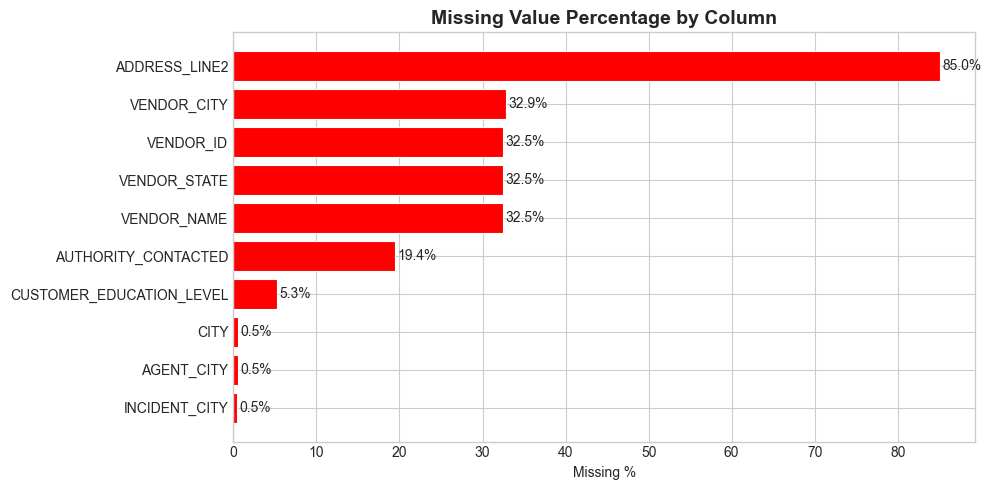

In [9]:
# Visualise Missing Values
missing_nonzero = missing_df[missing_df['Missing Count'] > 0]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(missing_nonzero.index, missing_nonzero['Missing %'],
               color="red", edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, missing_nonzero['Missing %']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)
ax.set_xlabel('Missing %')
ax.set_title('Missing Value Percentage by Column', fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [10]:
# Handle Missing Values

# ADDRESS_LINE2: optional apartment/suite field — drop (>85% missing, not useful)
df.drop(columns=['ADDRESS_LINE2'], inplace=True)

# CUSTOMER_EDUCATION_LEVEL: fill with mode (5.3% missing)
edu_mode = df['CUSTOMER_EDUCATION_LEVEL'].mode()[0]
df['CUSTOMER_EDUCATION_LEVEL'].fillna(edu_mode, inplace=True)
print(f"   CUSTOMER_EDUCATION_LEVEL filled with mode: '{edu_mode}'")

# AUTHORITY_CONTACTED: fill with 'None' (no authority contacted — informative category)
df['AUTHORITY_CONTACTED'].fillna('None', inplace=True)
print("   AUTHORITY_CONTACTED: NaN → 'None'")

# VENDOR_ID / VENDOR_NAME / VENDOR_STATE / VENDOR_CITY: fill with 'No_Vendor'
for col in ['VENDOR_ID', 'VENDOR_NAME', 'VENDOR_STATE', 'VENDOR_CITY']:
    if col in df.columns:
        df[col].fillna('No_Vendor', inplace=True)
print("   Vendor columns: NaN → 'No_Vendor'")

# CITY, INCIDENT_CITY: fill with mode
for col in ['CITY', 'INCIDENT_CITY']:
    mode_val = df[col].mode()[0]
    df[col].fillna(mode_val, inplace=True)
    print(f"   {col}: filled with mode '{mode_val}'")

# AGENT_JOIN_DATE: fill with median date (as string)
df['AGENT_JOIN_DATE'].fillna(df['AGENT_JOIN_DATE'].mode()[0], inplace=True)

# Verify
remaining = df.isnull().sum().sum()
print(f"\n Missing values after cleaning: {remaining}")

   CUSTOMER_EDUCATION_LEVEL filled with mode: 'Bachelor'
   AUTHORITY_CONTACTED: NaN → 'None'
   Vendor columns: NaN → 'No_Vendor'
   CITY: filled with mode 'Fayetteville'
   INCIDENT_CITY: filled with mode 'Manchester'

 Missing values after cleaning: 15650


In [11]:
# Duplicate Rows
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")
if dupes > 0:
    df.drop_duplicates(inplace=True)
    print(f"Removed {dupes} duplicates. New shape: {df.shape}")
else:
    print(" No duplicate rows found.")

Duplicate rows: 0
 No duplicate rows found.


In [12]:
# 2.5  Drop Useless / Leakage Columns
# PII / Free-text / ID columns → not useful for modelling
drop_cols = [
    'TRANSACTION_ID', 'CUSTOMER_ID', 'POLICY_NUMBER',
    'CUSTOMER_NAME', 'ADDRESS_LINE1', 'SSN',
    'ACCT_NUMBER', 'ROUTING_NUMBER',           # bank account details (PII)
    'EMP_ACCT_NUMBER', 'EMP_ROUTING_NUMBER',   # (if still present)
    'AGENT_ID', 'VENDOR_ID', 'VENDOR_NAME',    # IDs and free-text names
    'AGENT_CITY', 'AGENT_STATE',               # agent location (low signal)
    'VENDOR_CITY', 'VENDOR_STATE',
]

# Drop only columns that exist
drop_cols = [c for c in drop_cols if c in df.columns]
df.drop(columns=drop_cols, inplace=True)
print(f"Dropped {len(drop_cols)} ID/PII/useless columns.")
print(f"Remaining shape: {df.shape}")

Dropped 15 ID/PII/useless columns.
Remaining shape: (10000, 28)


In [13]:
# Parse Date Columns Extract Useful Parts
date_cols = ['TXN_DATE_TIME', 'POLICY_EFF_DT', 'LOSS_DT', 'REPORT_DT', 'AGENT_JOIN_DATE']

for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

print(" Date columns parsed to datetime.")
df[date_cols].dtypes

 Date columns parsed to datetime.


TXN_DATE_TIME      datetime64[us]
POLICY_EFF_DT      datetime64[us]
LOSS_DT            datetime64[us]
REPORT_DT          datetime64[us]
AGENT_JOIN_DATE    datetime64[us]
dtype: object

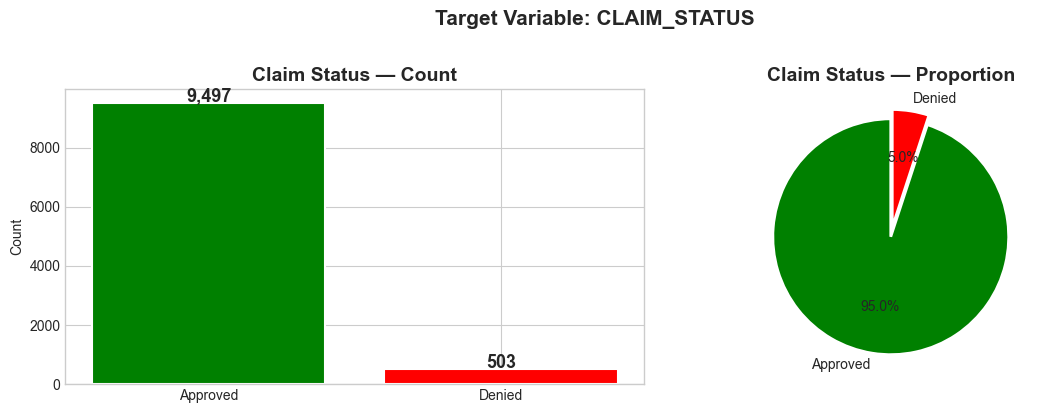


Class Distribution:
   Approved  : 9,497  (95.0%)
   Denied    : 503  (5.0%)

Imbalance Ratio: 18.9:1 (Approved:Denied)


In [14]:
# Target Variable Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['CLAIM_STATUS'].value_counts()
label_map = {'A': 'Approved', 'D': 'Denied'}
labels = [label_map[k] for k in counts.index]

# Count bar
axes[0].bar(labels, counts.values, color=COLORS, edgecolor='white', linewidth=1.5)
for i, cnt in enumerate(counts.values):
    axes[0].text(i, cnt + 50, f'{cnt:,}', ha='center', fontsize=13, fontweight='bold')
axes[0].set_title('Claim Status — Count', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')

# Pie chart
axes[1].pie(counts.values, labels=labels, autopct='%1.1f%%',
            colors=COLORS, startangle=90, explode=(0, 0.08),
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Claim Status — Proportion', fontsize=14, fontweight='bold')

plt.suptitle('Target Variable: CLAIM_STATUS', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\nClass Distribution:")
for k, v in counts.items():
    print(f"   {label_map[k]:10s}: {v:,}  ({v/len(df)*100:.1f}%)")
print(f"\nImbalance Ratio: {counts['A']/counts['D']:.1f}:1 (Approved:Denied)")

## Step 3 Exploratory Data Analysis (EDA) <a id='3'></a>

We explore relationships between features and the target to understand:
- Which customer profiles are more likely to have denied claims?
- Which features are most predictive?
- Are there outliers or skewed distributions?

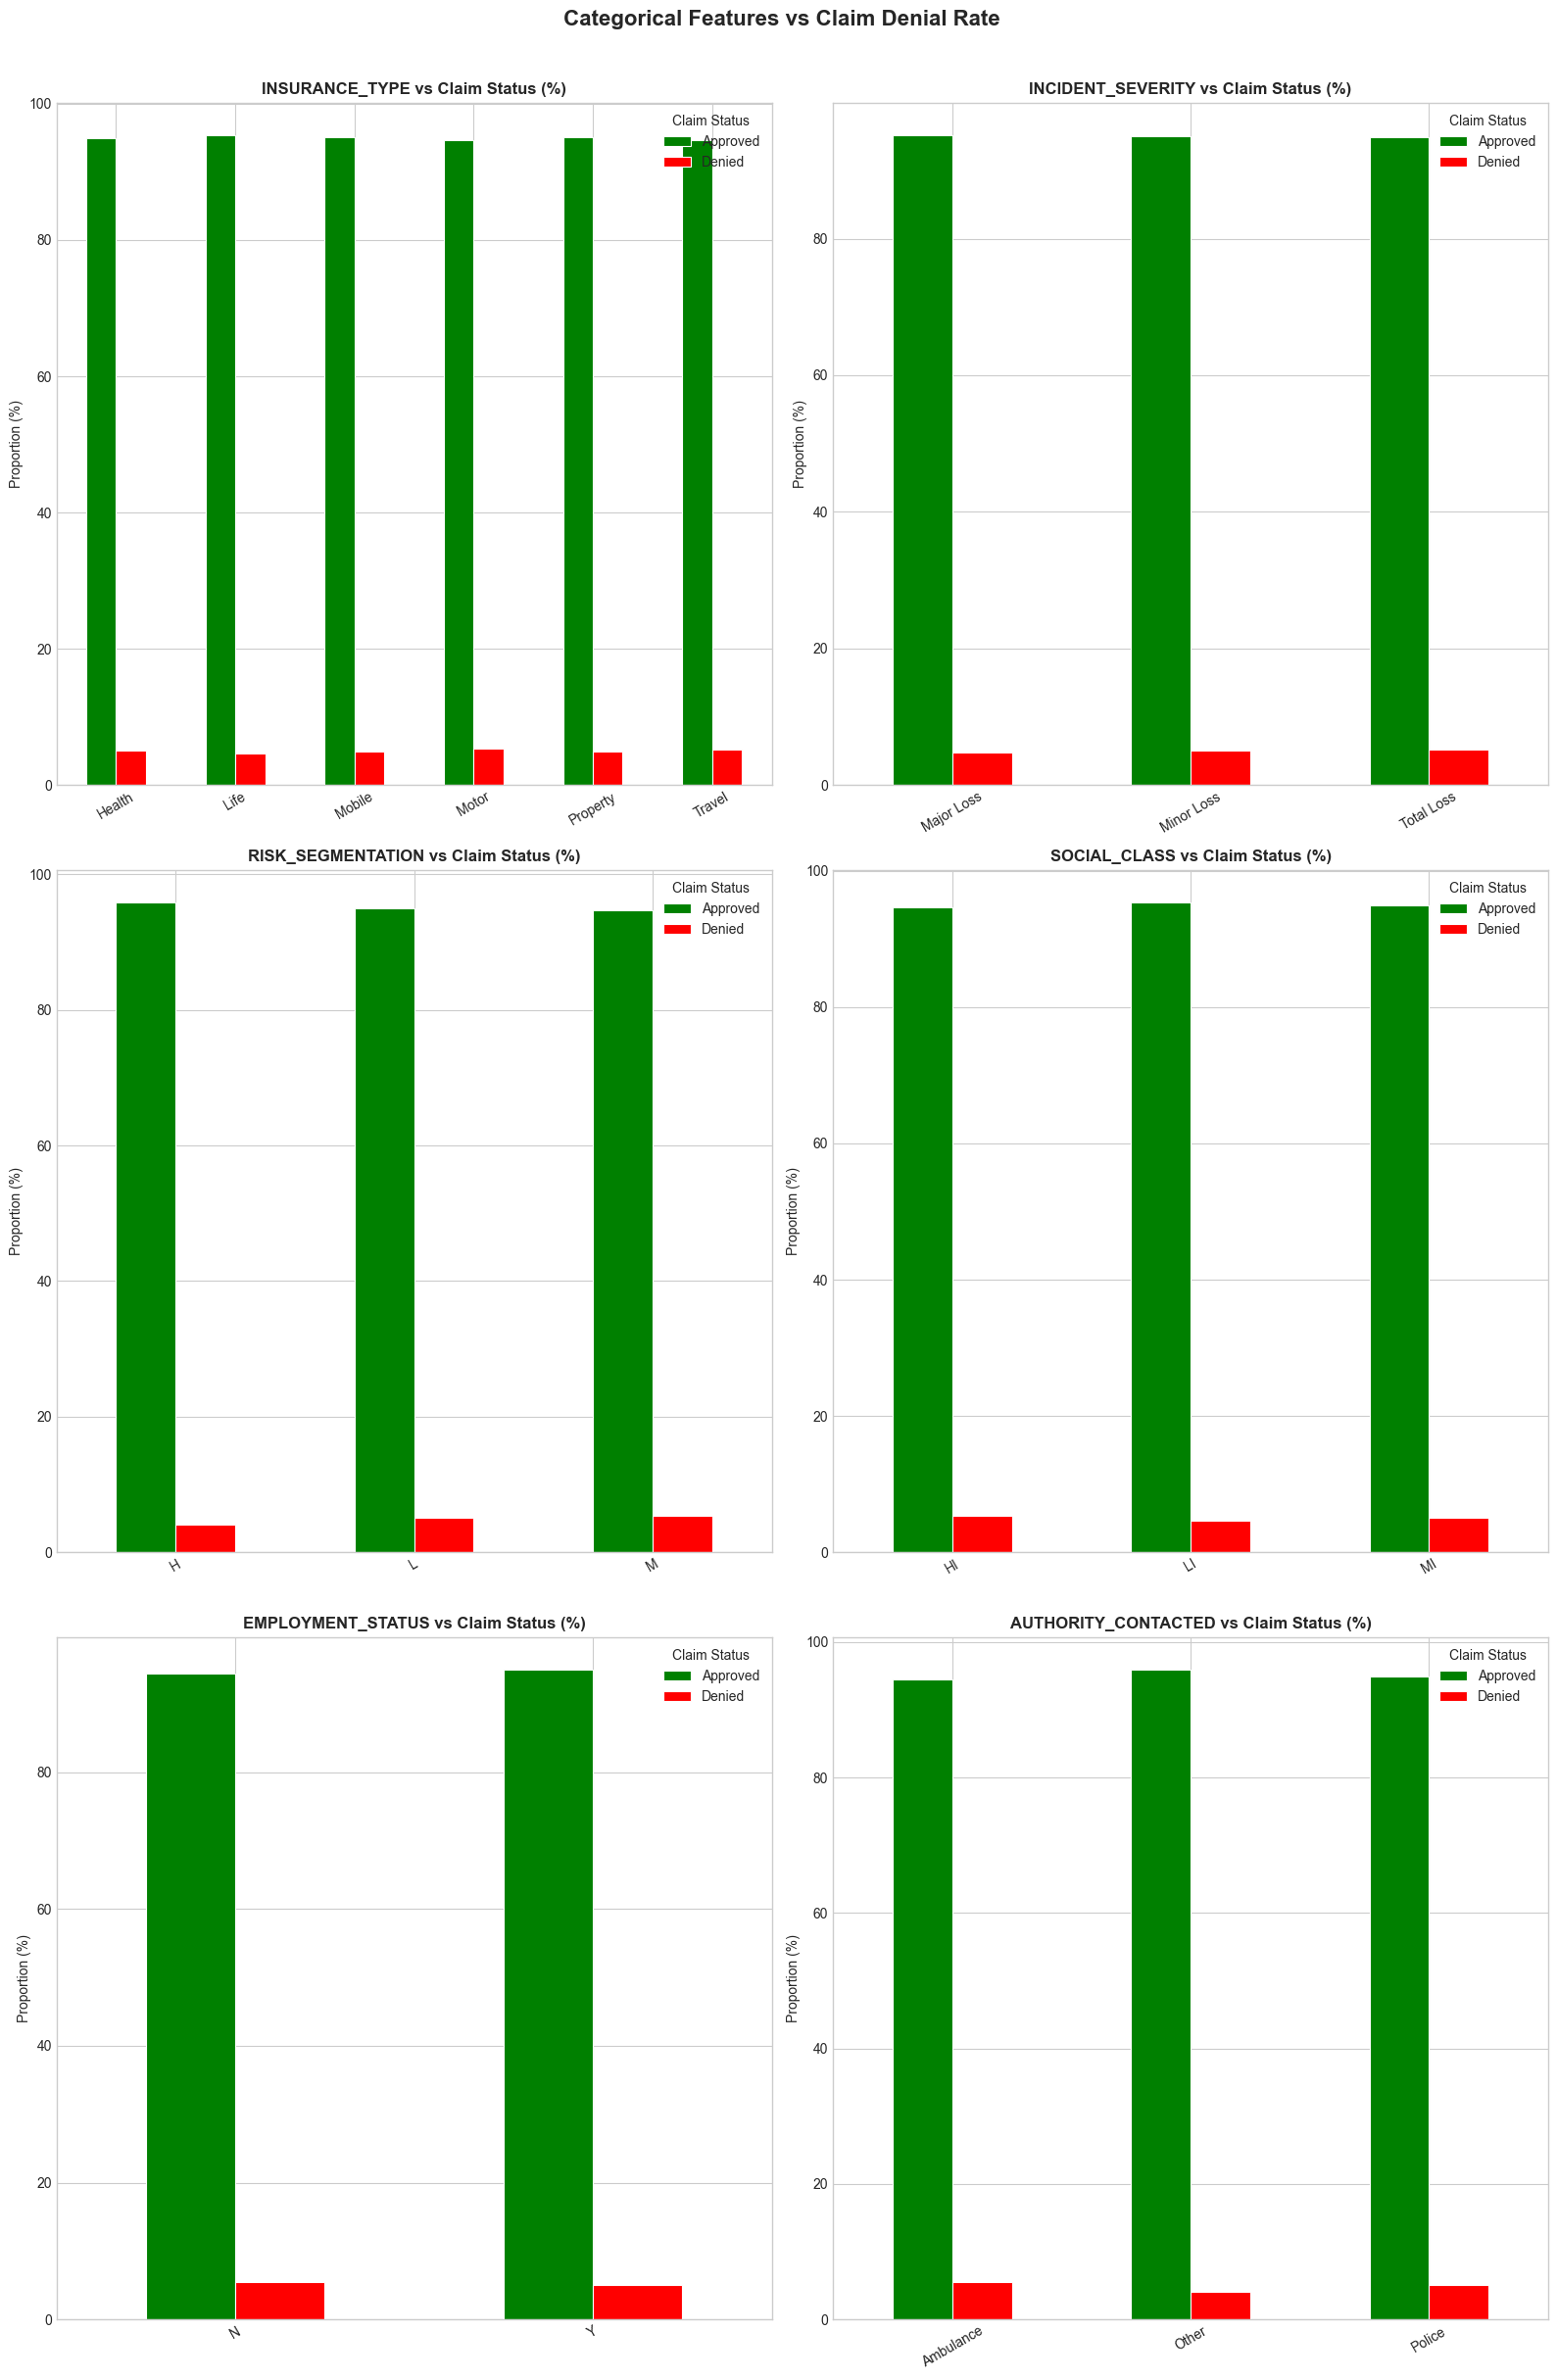

In [15]:
# Categorical Features vs CLAIM_STATUS
cat_features = ['INSURANCE_TYPE', 'INCIDENT_SEVERITY', 'RISK_SEGMENTATION','SOCIAL_CLASS','EMPLOYMENT_STATUS', 'AUTHORITY_CONTACTED']

fig, axes = plt.subplots(3, 2, figsize=(16, 24))
axes = axes.flatten()

for idx, col in enumerate(cat_features):
    ct = pd.crosstab(df[col], df['CLAIM_STATUS'], normalize='index') * 100
    ct.columns = ['Approved', 'Denied']
    ct.plot(kind='bar', ax=axes[idx], color=COLORS, edgecolor='white', linewidth=0.8)
    axes[idx].set_title(f'{col} vs Claim Status (%)', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('')
    axes[idx].set_ylabel('Proportion (%)')
    axes[idx].tick_params(axis='x', rotation=30)
    axes[idx].legend(title='Claim Status')

plt.suptitle(' Categorical Features vs Claim Denial Rate', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

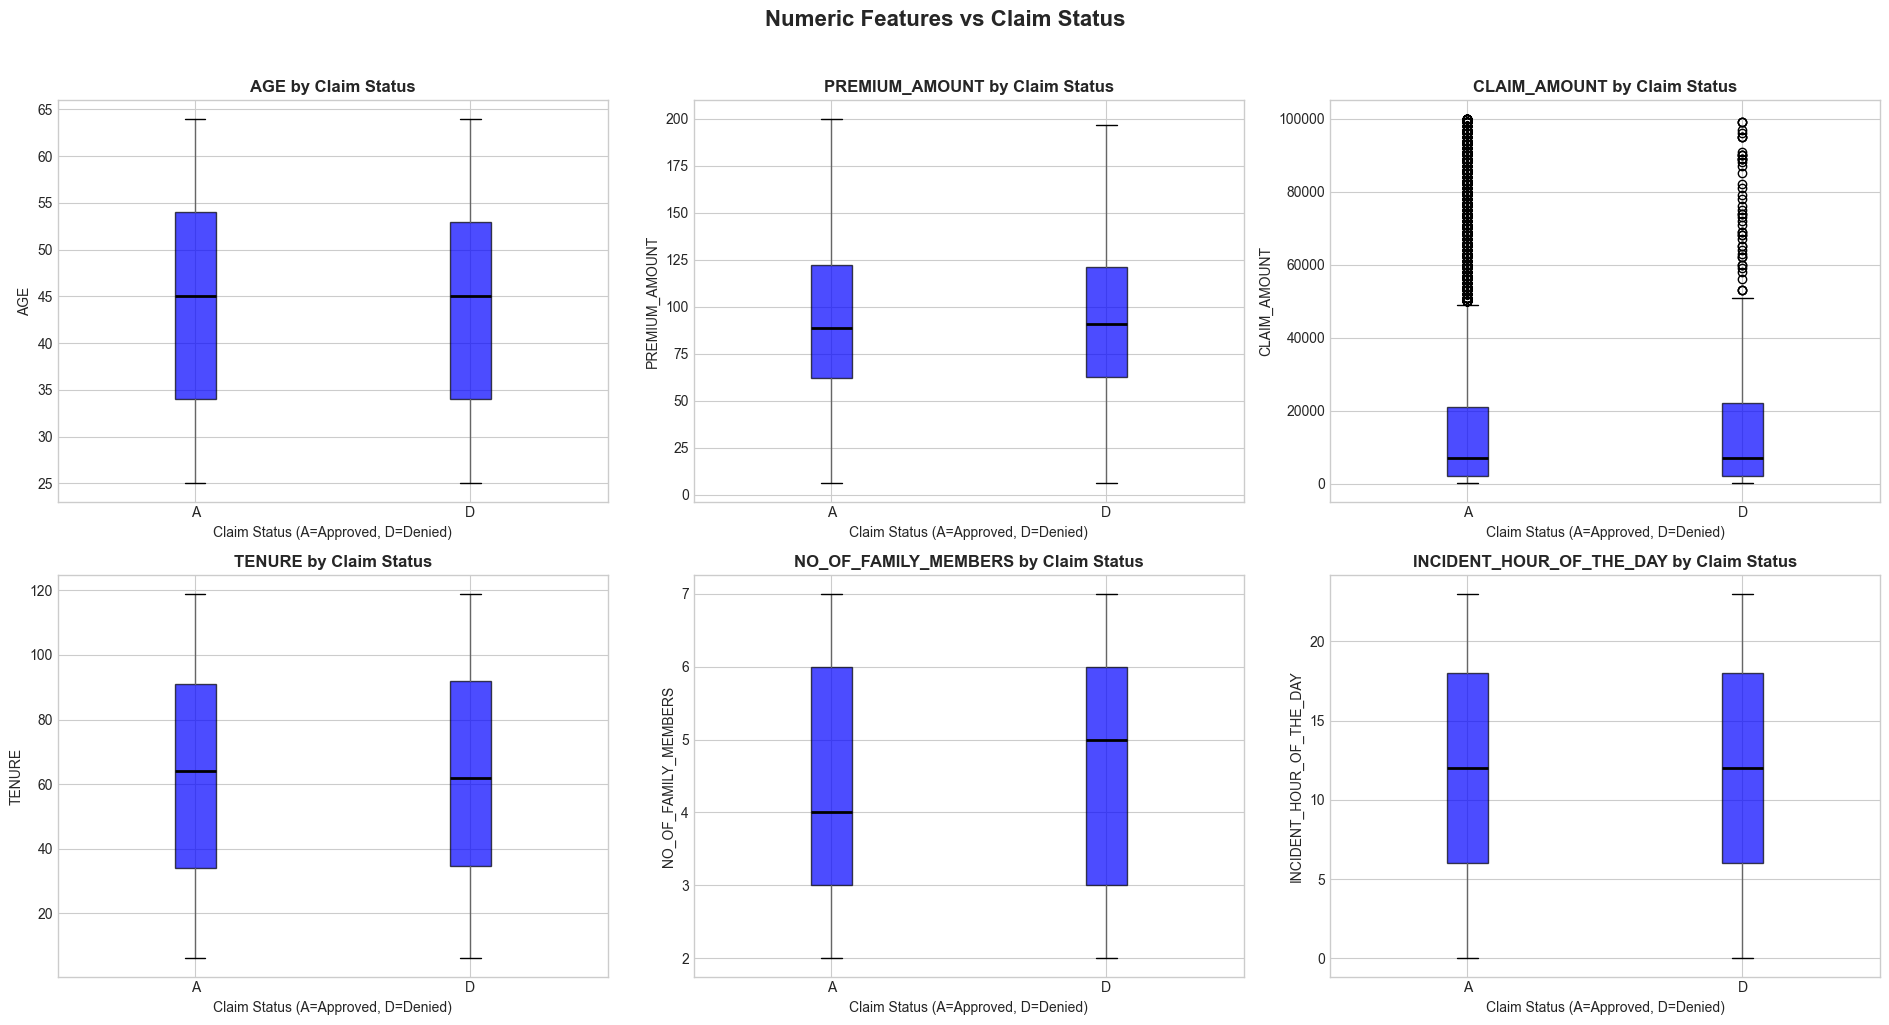

In [16]:
# Numeric Features vs CLAIM_STATUS (Box Plots)
num_features = ['AGE', 'PREMIUM_AMOUNT', 'CLAIM_AMOUNT',
                'TENURE', 'NO_OF_FAMILY_MEMBERS', 'INCIDENT_HOUR_OF_THE_DAY']

fig, axes = plt.subplots(2, 3, figsize=(19, 10))
axes = axes.flatten()

for idx, col in enumerate(num_features):
    df.boxplot(column=col, by='CLAIM_STATUS', ax=axes[idx],
               patch_artist=True,
               boxprops=dict(facecolor='Blue', alpha=0.7),
               medianprops=dict(color='black', linewidth=2))
    axes[idx].set_title(f'{col} by Claim Status', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Claim Status (A=Approved, D=Denied)')
    axes[idx].set_ylabel(col)

plt.suptitle('')
plt.suptitle('Numeric Features vs Claim Status', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

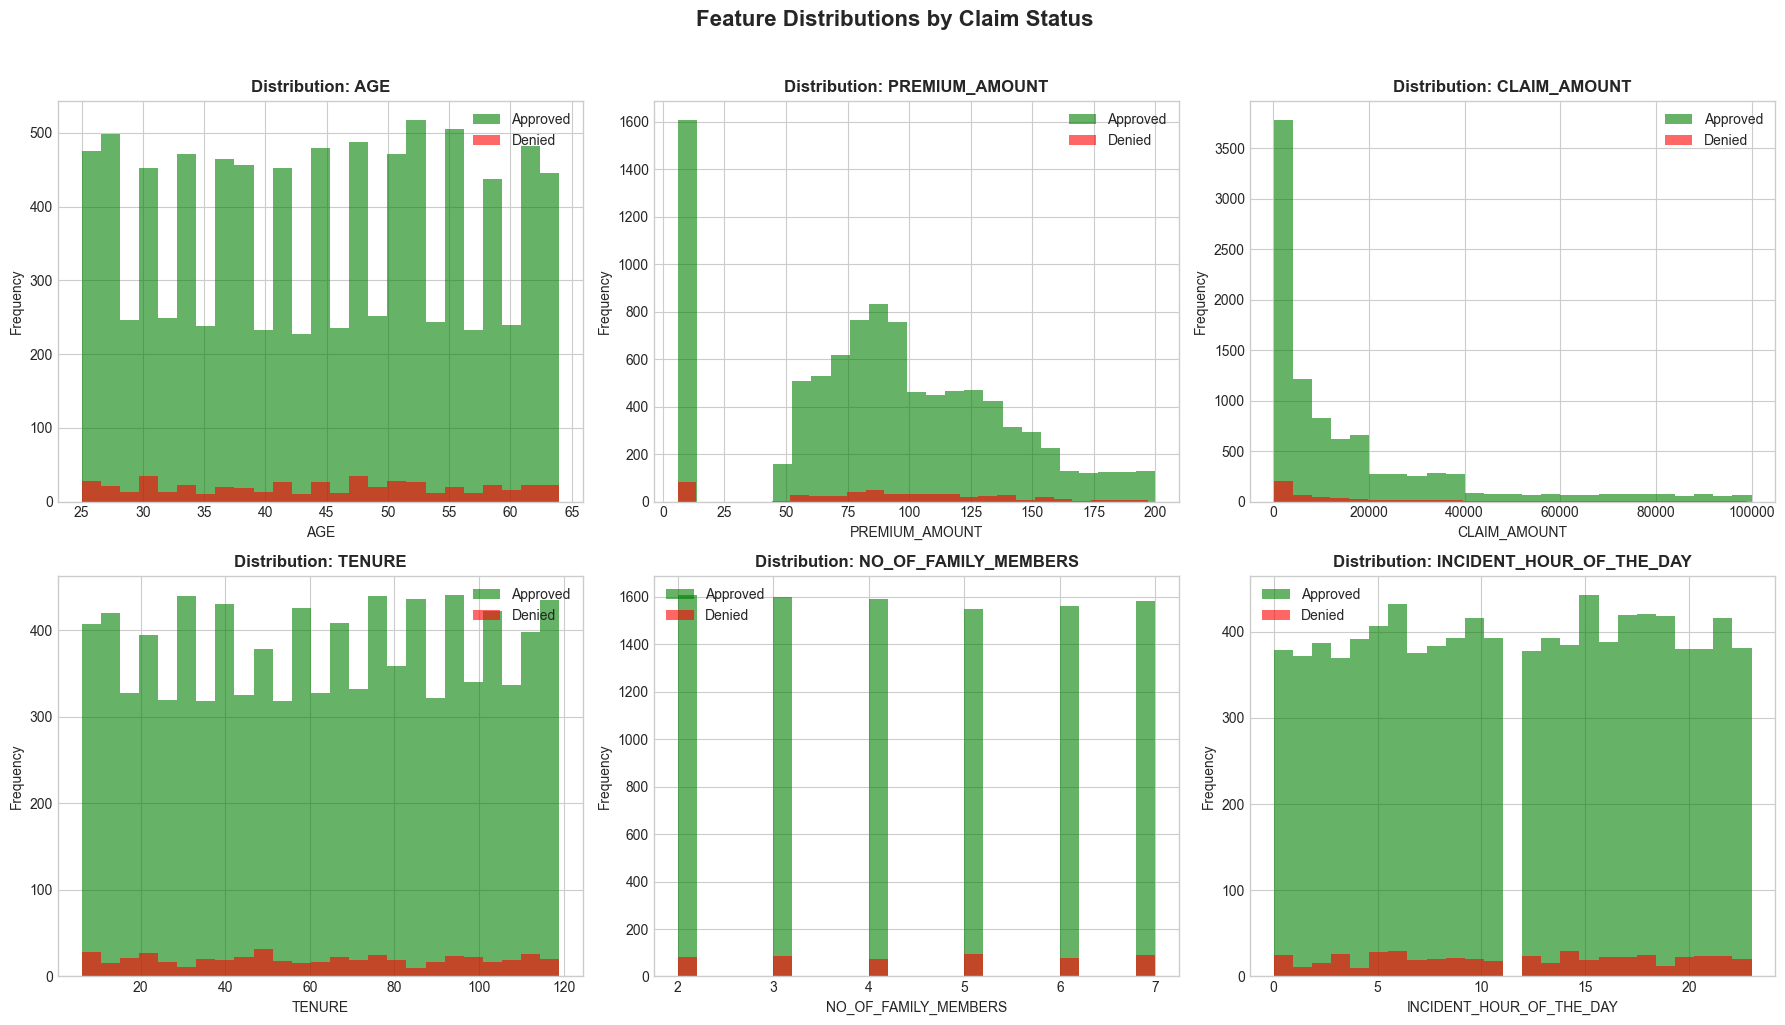

In [17]:
# Distribution of Numeric Features (Histograms)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, col in enumerate(num_features):
    for status, color in zip(['A', 'D'], COLORS):
        axes[idx].hist(df[df['CLAIM_STATUS'] == status][col].dropna(),
                       bins=25, alpha=0.6, color=color,
                       label=f'{"Approved" if status=="A" else "Denied"}')
    axes[idx].set_title(f'Distribution: {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].legend()

plt.suptitle('Feature Distributions by Claim Status', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

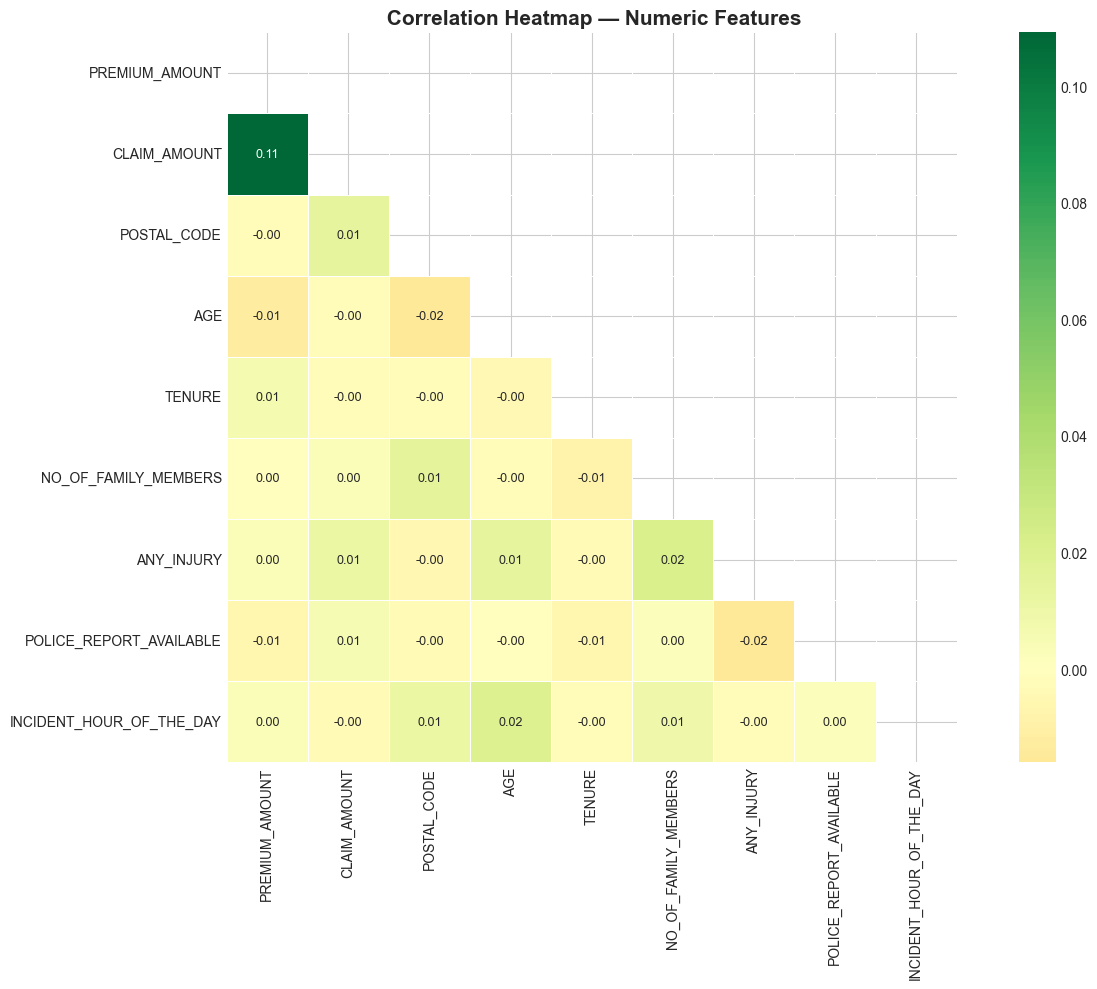

In [18]:
# Correlation Heatmap (Numeric Features)
numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(14, 10))
corr = numeric_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, linecolor='white',
            annot_kws={'size': 9}, square=True)
plt.title(' Correlation Heatmap — Numeric Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

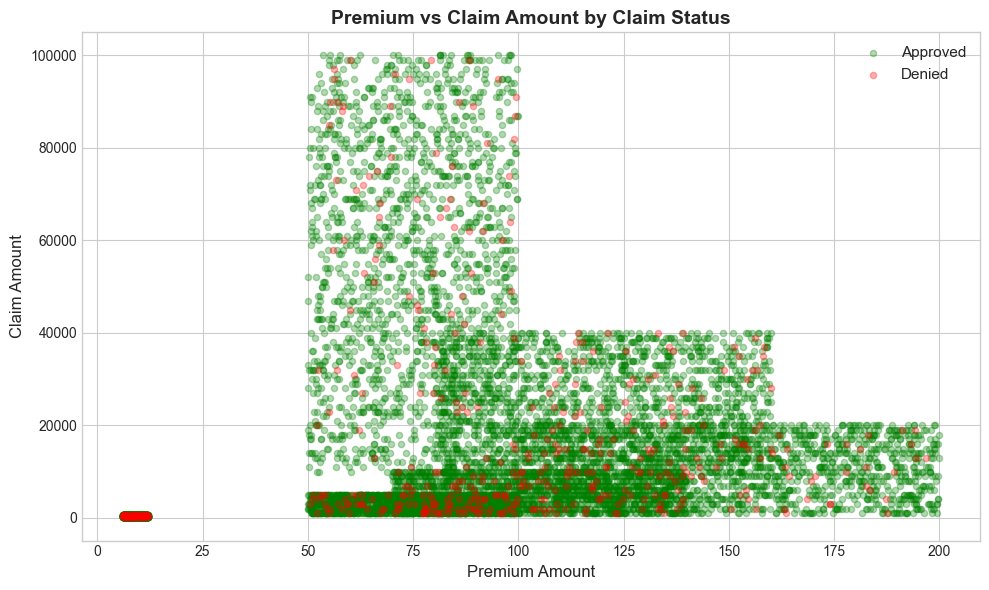

In [19]:
# Claim Amount vs Premium Amount (Scatter)
fig, ax = plt.subplots(figsize=(10, 6))
for status, color, label in zip(['A', 'D'], COLORS, ['Approved', 'Denied']):
    subset = df[df['CLAIM_STATUS'] == status]
    ax.scatter(subset['PREMIUM_AMOUNT'], subset['CLAIM_AMOUNT'],
               alpha=0.3, c=color, label=label, s=20)
ax.set_xlabel('Premium Amount', fontsize=12)
ax.set_ylabel('Claim Amount', fontsize=12)
ax.set_title('Premium vs Claim Amount by Claim Status', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

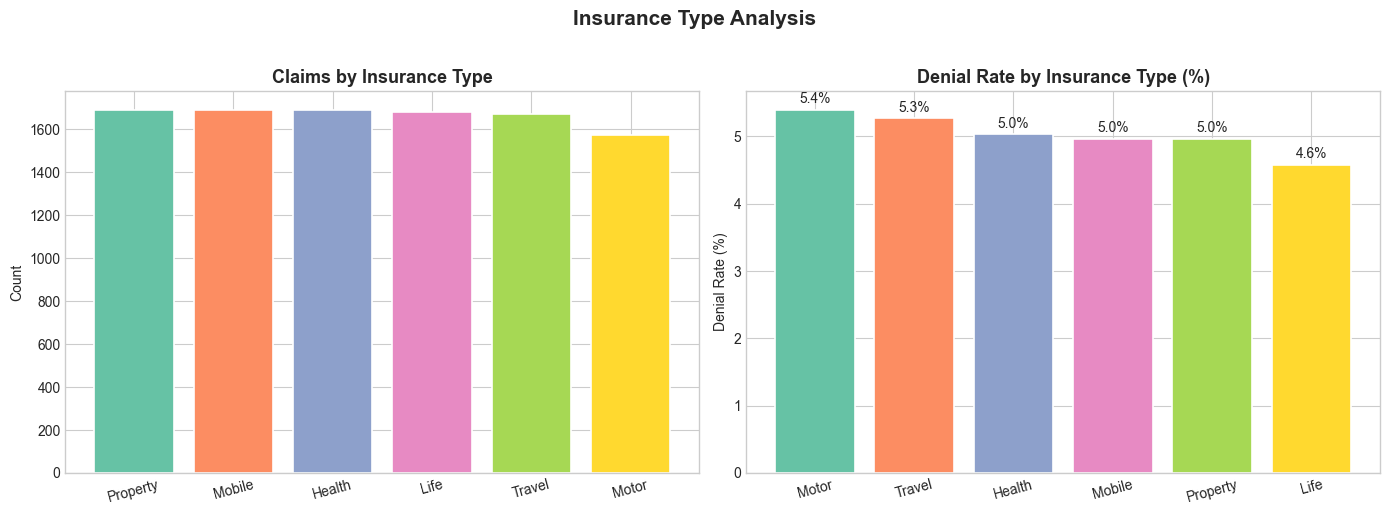

In [20]:
# Insurance Type Distribution 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ins_counts = df['INSURANCE_TYPE'].value_counts()
axes[0].bar(ins_counts.index, ins_counts.values,
            color=sns.color_palette('Set2', len(ins_counts)),
            edgecolor='white', linewidth=1.2)
axes[0].set_title('Claims by Insurance Type', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=15)

denial_rate = df.groupby('INSURANCE_TYPE')['CLAIM_STATUS'].apply(
    lambda x: (x == 'D').mean() * 100
).sort_values(ascending=False)
colors_dr = sns.color_palette('Set2', len(denial_rate))
axes[1].bar(denial_rate.index, denial_rate.values, color=colors_dr,
            edgecolor='white', linewidth=1.2)
for i, v in enumerate(denial_rate.values):
    axes[1].text(i, v + 0.1, f'{v:.1f}%', ha='center', fontsize=10)
axes[1].set_title('Denial Rate by Insurance Type (%)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Denial Rate (%)')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Insurance Type Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Step 4 Preprocessing <a id='4'></a>

1. Encode the **target variable** numerically
2. Extract temporal features from date columns and drop originals
3. Drop remaining high-cardinality / non-informative columns
4. Separate features (X) and target (y)

In [21]:
# Encode Target Variable
# A = Approved = 1  |  D = Denied = 0
df['CLAIM_STATUS'] = df['CLAIM_STATUS'].map({'A': 1, 'D': 0})
print("Target encoded — A:1 (Approved), D:0 (Denied)")
print(df['CLAIM_STATUS'].value_counts())

Target encoded — A:1 (Approved), D:0 (Denied)
CLAIM_STATUS
1    9497
0     503
Name: count, dtype: int64


In [22]:
# 4.2  Extract Features from Date Columns
def days_between(df, col1, col2, new_col):
    """Compute absolute days between two datetime columns."""
    df[new_col] = (df[col1] - df[col2]).dt.days.abs()
    return df

txn_ref = df['TXN_DATE_TIME']

# Policy age at transaction
df = days_between(df, 'TXN_DATE_TIME', 'POLICY_EFF_DT', 'POLICY_AGE_DAYS')

# Days between loss and reporting
df = days_between(df, 'REPORT_DT', 'LOSS_DT', 'REPORT_DELAY_DAYS')

# Transaction month and day-of-week (seasonality signals)
df['TXN_MONTH']   = df['TXN_DATE_TIME'].dt.month
df['TXN_DAYOFWK'] = df['TXN_DATE_TIME'].dt.dayofweek   # 0=Mon … 6=Sun

# Agent seniority at transaction
df = days_between(df, 'TXN_DATE_TIME', 'AGENT_JOIN_DATE', 'AGENT_SENIORITY_DAYS')

# Drop original date columns
date_drop = ['TXN_DATE_TIME', 'POLICY_EFF_DT', 'LOSS_DT', 'REPORT_DT', 'AGENT_JOIN_DATE']
df.drop(columns=[c for c in date_drop if c in df.columns], inplace=True)

print(f" Date features extracted. Shape: {df.shape}")
print("New columns:", ['POLICY_AGE_DAYS','REPORT_DELAY_DAYS','TXN_MONTH','TXN_DAYOFWK','AGENT_SENIORITY_DAYS'])

 Date features extracted. Shape: (10000, 28)
New columns: ['POLICY_AGE_DAYS', 'REPORT_DELAY_DAYS', 'TXN_MONTH', 'TXN_DAYOFWK', 'AGENT_SENIORITY_DAYS']


In [23]:
# 4.3  Drop Remaining High-Cardinality Columns
high_card = ['CITY', 'STATE', 'INCIDENT_CITY', 'INCIDENT_STATE', 'POSTAL_CODE']
df.drop(columns=[c for c in high_card if c in df.columns], inplace=True)

print(f"Dropped high-cardinality location columns. Shape: {df.shape}")
print("\nFinal columns:")
print(df.columns.tolist())

Dropped high-cardinality location columns. Shape: (10000, 23)

Final columns:
['INSURANCE_TYPE', 'PREMIUM_AMOUNT', 'CLAIM_AMOUNT', 'MARITAL_STATUS', 'AGE', 'TENURE', 'EMPLOYMENT_STATUS', 'NO_OF_FAMILY_MEMBERS', 'RISK_SEGMENTATION', 'HOUSE_TYPE', 'SOCIAL_CLASS', 'CUSTOMER_EDUCATION_LEVEL', 'CLAIM_STATUS', 'INCIDENT_SEVERITY', 'AUTHORITY_CONTACTED', 'ANY_INJURY', 'POLICE_REPORT_AVAILABLE', 'INCIDENT_HOUR_OF_THE_DAY', 'POLICY_AGE_DAYS', 'REPORT_DELAY_DAYS', 'TXN_MONTH', 'TXN_DAYOFWK', 'AGENT_SENIORITY_DAYS']


In [24]:
# Separate Features and Target 
X = df.drop(columns=['CLAIM_STATUS'])
y = df['CLAIM_STATUS']

print(f"Features (X): {X.shape}")
print(f"Target  (y): {y.shape}")
print(f"\nClass distribution:\n{y.value_counts()}")

Features (X): (10000, 22)
Target  (y): (10000,)

Class distribution:
CLAIM_STATUS
1    9497
0     503
Name: count, dtype: int64


## Step 5 Feature Engineering <a id='5'></a>

We create new meaningful features from existing ones to improve model performance:
1. **Claim-to-Premium Ratio**  how much the claim is relative to premium
2. **Loss Reporting Urgency**  binned delay from loss to report
3. **High Risk Flag** combines risk segmentation + injury + police report
4. **Customer Financial Stress Index** claim amount per family member

In [25]:
# Claim-to-Premium Ratio
X['CLAIM_PREMIUM_RATIO'] = X['CLAIM_AMOUNT'] / (X['PREMIUM_AMOUNT'] + 1)
print("Feature created: CLAIM_PREMIUM_RATIO")
print(X['CLAIM_PREMIUM_RATIO'].describe())

Feature created: CLAIM_PREMIUM_RATIO
count    10000.000000
mean       196.006490
std        301.817289
min          4.988775
25%         37.043897
50%         71.737301
75%        192.933808
max       1828.487841
Name: CLAIM_PREMIUM_RATIO, dtype: float64


In [26]:
#  Report Delay Category
def categorize_delay(days):
    if days <= 2:
        return 'Immediate'
    elif days <= 7:
        return 'Within_Week'
    elif days <= 30:
        return 'Within_Month'
    else:
        return 'Late'

X['REPORT_DELAY_CAT'] = X['REPORT_DELAY_DAYS'].apply(categorize_delay)
print("Feature created: REPORT_DELAY_CAT")
print(X['REPORT_DELAY_CAT'].value_counts())

Feature created: REPORT_DELAY_CAT
REPORT_DELAY_CAT
Within_Week    6383
Immediate      3617
Name: count, dtype: int64


In [27]:
# 5.3  High Risk Flag
# High risk if: RISK_SEGMENTATION==H  AND  ANY_INJURY==1  AND  POLICE_REPORT_AVAILABLE==1
X['HIGH_RISK_FLAG'] = (
    (X['RISK_SEGMENTATION'] == 'H').astype(int) +
    X['ANY_INJURY'] +
    X['POLICE_REPORT_AVAILABLE']
)
# Binary: 3 = all three triggers fired
X['HIGH_RISK_FLAG'] = (X['HIGH_RISK_FLAG'] == 3).astype(int)
print("Feature created: HIGH_RISK_FLAG")
print(X['HIGH_RISK_FLAG'].value_counts())

Feature created: HIGH_RISK_FLAG
HIGH_RISK_FLAG
0    9282
1     718
Name: count, dtype: int64


In [28]:
# Claim Amount per Family Member
X['CLAIM_PER_MEMBER'] = X['CLAIM_AMOUNT'] / (X['NO_OF_FAMILY_MEMBERS'] + 1)
print("Feature created: CLAIM_PER_MEMBER")
print(X['CLAIM_PER_MEMBER'].describe())

Feature created: CLAIM_PER_MEMBER
count    10000.000000
mean      3368.337083
std       4898.172536
min         12.500000
25%        333.333333
50%       1375.000000
75%       4285.714286
max      33333.333333
Name: CLAIM_PER_MEMBER, dtype: float64


In [29]:
# Policy Maturity Category
X['POLICY_MATURITY'] = pd.cut(
    X['POLICY_AGE_DAYS'],
    bins=[-1, 365, 1095, 1825, float('inf')],
    labels=['New_Policy', 'Young_Policy', 'Mature_Policy', 'Old_Policy']
)
print("Feature created: POLICY_MATURITY")
print(X['POLICY_MATURITY'].value_counts())
print(f"\nFeature Engineering complete. Shape: {X.shape}")

Feature created: POLICY_MATURITY
POLICY_MATURITY
Old_Policy       5806
Mature_Policy    2058
Young_Policy     1913
New_Policy        223
Name: count, dtype: int64

Feature Engineering complete. Shape: (10000, 27)


## Step 6 Encoding <a id='6'></a>

We convert all categorical columns to numeric representations:
**Label / Ordinal Encoding** for ordinal features (risk level, social class, education)
**One-Hot Encoding** for nominal features (insurance type, house type, etc.)

In [30]:
# Identify Categorical Columns
cat_cols = X.select_dtypes(include=['object', 'category', 'str']).columns.tolist()
print(f"Categorical columns ({len(cat_cols)}):")
for c in cat_cols:
    print(f" {c:35s}  unique={X[c].nunique()}  sample={X[c].unique()[:4].tolist()}")

Categorical columns (11):
 INSURANCE_TYPE                       unique=6  sample=['Health', 'Property', 'Travel', 'Life']
 MARITAL_STATUS                       unique=2  sample=['Y', 'N']
 EMPLOYMENT_STATUS                    unique=2  sample=['Y', 'N']
 RISK_SEGMENTATION                    unique=3  sample=['L', 'M', 'H']
 HOUSE_TYPE                           unique=3  sample=['Own', 'Rent', 'Mortgage']
 SOCIAL_CLASS                         unique=3  sample=['LI', 'MI', 'HI']
 CUSTOMER_EDUCATION_LEVEL             unique=6  sample=['Bachelor', 'PhD', 'Masters', 'College']
 INCIDENT_SEVERITY                    unique=3  sample=['Major Loss', 'Total Loss', 'Minor Loss']
 AUTHORITY_CONTACTED                  unique=3  sample=['Police', 'Ambulance', nan, 'Other']
 REPORT_DELAY_CAT                     unique=2  sample=['Within_Week', 'Immediate']
 POLICY_MATURITY                      unique=4  sample=['Mature_Policy', 'Young_Policy', 'New_Policy', 'Old_Policy']


In [31]:
# Ordinal Encoding
# Risk Segmentation: L < M < H
X['RISK_SEGMENTATION'] = X['RISK_SEGMENTATION'].map({'L': 0, 'M': 1, 'H': 2})

# Social Class: LI < MI < HI
X['SOCIAL_CLASS'] = X['SOCIAL_CLASS'].map({'LI': 0, 'MI': 1, 'HI': 2})

# Customer Education Level
edu_order = {'High School': 0, 'College': 1, 'Bachelor': 2, 'Masters': 3, 'PhD': 4, 'MD': 5}
X['CUSTOMER_EDUCATION_LEVEL'] = X['CUSTOMER_EDUCATION_LEVEL'].map(edu_order)
X['CUSTOMER_EDUCATION_LEVEL'].fillna(edu_order['Bachelor'], inplace=True)  # fallback

# Incident Severity: Minor < Major < Total
X['INCIDENT_SEVERITY'] = X['INCIDENT_SEVERITY'].map({'Minor Loss': 0, 'Major Loss': 1, 'Total Loss': 2})

# Report Delay Category
delay_order = {'Immediate': 0, 'Within_Week': 1, 'Within_Month': 2, 'Late': 3}
X['REPORT_DELAY_CAT'] = X['REPORT_DELAY_CAT'].map(delay_order)

# Policy Maturity
maturity_order = {'New_Policy': 0, 'Young_Policy': 1, 'Mature_Policy': 2, 'Old_Policy': 3}
X['POLICY_MATURITY'] = X['POLICY_MATURITY'].map(maturity_order)

print("Ordinal encoding applied to: RISK_SEGMENTATION, SOCIAL_CLASS, CUSTOMER_EDUCATION_LEVEL,")
print("INCIDENT_SEVERITY, REPORT_DELAY_CAT, POLICY_MATURITY")

Ordinal encoding applied to: RISK_SEGMENTATION, SOCIAL_CLASS, CUSTOMER_EDUCATION_LEVEL,
INCIDENT_SEVERITY, REPORT_DELAY_CAT, POLICY_MATURITY


In [32]:
#Binary Encoding (Y/N columns)
binary_map = {'Y': 1, 'N': 0}
for col in ['MARITAL_STATUS', 'EMPLOYMENT_STATUS']:
    X[col] = X[col].map(binary_map)
print("Binary encoding applied to: MARITAL_STATUS, EMPLOYMENT_STATUS")

Binary encoding applied to: MARITAL_STATUS, EMPLOYMENT_STATUS


In [33]:
#One-Hot Encoding (Nominal columns) 
nominal_cols = ['INSURANCE_TYPE', 'HOUSE_TYPE', 'AUTHORITY_CONTACTED']
X = pd.get_dummies(X, columns=nominal_cols, drop_first=True)
print(f"One-Hot encoding applied to: {nominal_cols}")
print(f"Shape after OHE: {X.shape}")

One-Hot encoding applied to: ['INSURANCE_TYPE', 'HOUSE_TYPE', 'AUTHORITY_CONTACTED']
Shape after OHE: (10000, 33)


In [34]:
# Final Check & NaN Audit
remaining_cat = X.select_dtypes(include=['object','category','str']).columns.tolist()
if remaining_cat:
    print(f"Still categorical: {remaining_cat}")
else:
    print("All columns are now numeric!")

# Convert any bool columns from get_dummies to int
bool_cols = X.select_dtypes(include='bool').columns.tolist()
X[bool_cols] = X[bool_cols].astype(int)

# NaN Audit
nan_report = X.isnull().sum()
nan_report = nan_report[nan_report > 0]
if nan_report.empty:
    print("No NaN values in feature matrix X.")
else:
    print(f"NaN values found after encoding:")
    print(nan_report)

print(f"\nFinal X shape: {X.shape}")
X.head(3)

Still categorical: ['POLICY_MATURITY']
NaN values found after encoding:
CUSTOMER_EDUCATION_LEVEL    529
dtype: int64

Final X shape: (10000, 33)


,PREMIUM_AMOUNT,CLAIM_AMOUNT,MARITAL_STATUS,AGE,TENURE,EMPLOYMENT_STATUS,NO_OF_FAMILY_MEMBERS,RISK_SEGMENTATION,SOCIAL_CLASS,CUSTOMER_EDUCATION_LEVEL,...,POLICY_MATURITY,INSURANCE_TYPE_Life,INSURANCE_TYPE_Mobile,INSURANCE_TYPE_Motor,INSURANCE_TYPE_Property,INSURANCE_TYPE_Travel,HOUSE_TYPE_Own,HOUSE_TYPE_Rent,AUTHORITY_CONTACTED_Other,AUTHORITY_CONTACTED_Police
0,157.13,9000,1,54,89,1,3,0,0,2.0,...,2,0,0,0,0,0,1,0,0,1
1,141.71,26000,0,61,80,1,4,0,1,2.0,...,1,0,0,0,1,0,0,1,0,0
2,157.24,13000,0,47,68,1,6,0,1,4.0,...,0,0,0,0,1,0,0,1,0,1


In [35]:
# Impute Remaining NaNs (Safety Net)
# Causes of residual NaN:
#   • POLICY_MATURITY: pd.cut returns NaN if value falls outside bin edges
#   • Ordinal maps: any unseen category → NaN
#   • Date arithmetic: NaT in date cols → NaN after .dt.days
#
# Fix: fill numeric NaN with column median, categorical NaN with mode.
# This MUST run before StandardScaler and SMOTE (both reject NaN input).

from sklearn.impute import SimpleImputer

# Numeric columns → median imputation
num_cols = X.select_dtypes(include='number').columns.tolist()
imp_num = SimpleImputer(strategy='median')
X[num_cols] = imp_num.fit_transform(X[num_cols])

# Safety check: confirm zero NaNs remain
remaining_nan = X.isnull().sum().sum()
assert remaining_nan == 0, f"Still {remaining_nan} NaNs after imputation!"
print(f"All NaNs imputed with median strategy.")
print(f"Remaining NaNs: {remaining_nan}")
print(f"X shape: {X.shape}")

All NaNs imputed with median strategy.
Remaining NaNs: 0
X shape: (10000, 33)


## Step 7 Data Standardization <a id='7'></a>

We apply **StandardScaler** (zero mean, unit variance) to all numeric features so that  
distance-based models (KNN, SVM, Logistic Regression) are not dominated by large-scale features.

We also perform a **Train-Test Split** (80/20, stratified) before fitting the scaler  
to avoid data leakage.

In [36]:
#7.1  Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f" Split Summary:")
print(f" X_train : {X_train.shape}")
print(f" X_test  : {X_test.shape}")
print(f" y_train distribution:\n{y_train.value_counts()}")
print(f" y_test  distribution:\n{y_test.value_counts()}")

 Split Summary:
 X_train : (8000, 33)
 X_test  : (2000, 33)
 y_train distribution:
CLAIM_STATUS
1    7598
0     402
Name: count, dtype: int64
 y_test  distribution:
CLAIM_STATUS
1    1899
0     101
Name: count, dtype: int64


In [37]:
#7.2  StandardScaler (fit on train only)
# Final NaN guard — asserts clean data before scaling
assert X_train.isnull().sum().sum() == 0, "X_train still has NaN — check encoding/imputation steps!"
assert X_test.isnull().sum().sum()  == 0, "X_test still has NaN — check encoding/imputation steps!"

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Convert back to DataFrame for readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X_test.columns)

print("StandardScaler applied — no NaN in scaled data.")
print("Before scaling — CLAIM_AMOUNT mean/std:", round(X_train['CLAIM_AMOUNT'].mean(),2), '/', round(X_train['CLAIM_AMOUNT'].std(),2))
print("After  scaling — CLAIM_AMOUNT mean/std:", round(X_train_scaled['CLAIM_AMOUNT'].mean(),4), '/', round(X_train_scaled['CLAIM_AMOUNT'].std(),4))

StandardScaler applied — no NaN in scaled data.
Before scaling — CLAIM_AMOUNT mean/std: 16581.6 / 22125.24
After  scaling — CLAIM_AMOUNT mean/std: 0.0 / 1.0001


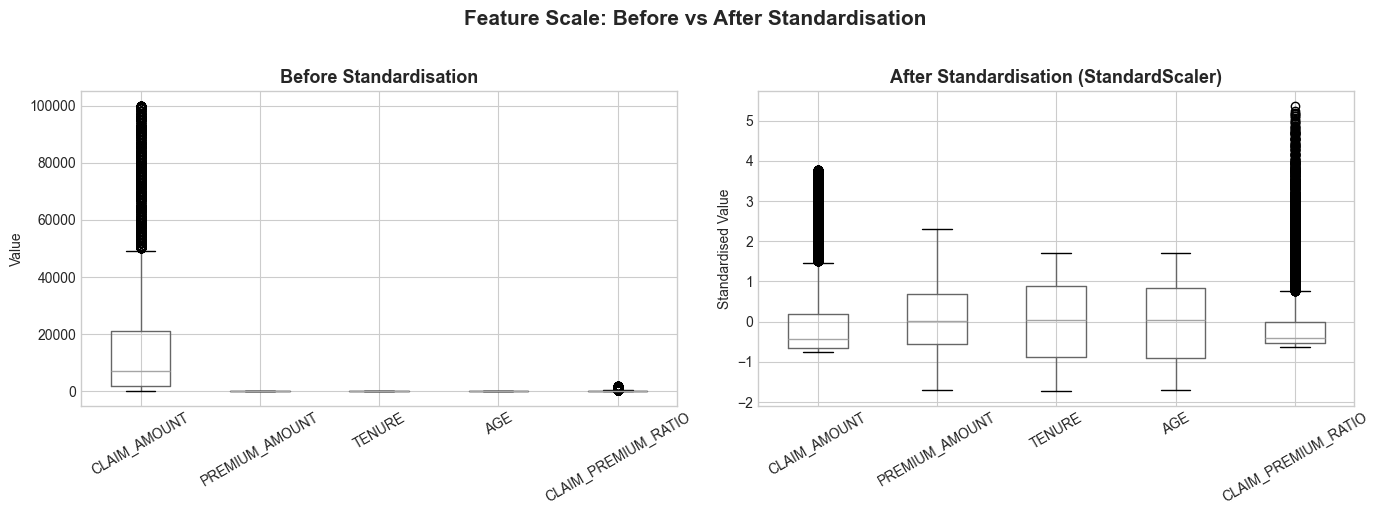

In [38]:
#7.3  Visualise Pre vs Post Standardisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_features = ['CLAIM_AMOUNT', 'PREMIUM_AMOUNT', 'TENURE', 'AGE', 'CLAIM_PREMIUM_RATIO']
X_train[top_features].boxplot(ax=axes[0])
axes[0].set_title('Before Standardisation', fontsize=13, fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)
axes[0].set_ylabel('Value')

X_train_scaled[top_features].boxplot(ax=axes[1])
axes[1].set_title('After Standardisation (StandardScaler)', fontsize=13, fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)
axes[1].set_ylabel('Standardised Value')

plt.suptitle('Feature Scale: Before vs After Standardisation', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Step 8 Imbalance Handling <a id='8'></a>

The target is **severely imbalanced** (~95% Approved vs ~5% Denied).  
We will apply **SMOTE** (Synthetic Minority Over-sampling Technique) on the training set only  
to generate synthetic minority (Denied) samples.

We will also compare three strategies:
1. **No resampling** (baseline)
2. **SMOTE** (over-sample minority)
3. **Random Under-sampling** (reduce majority)

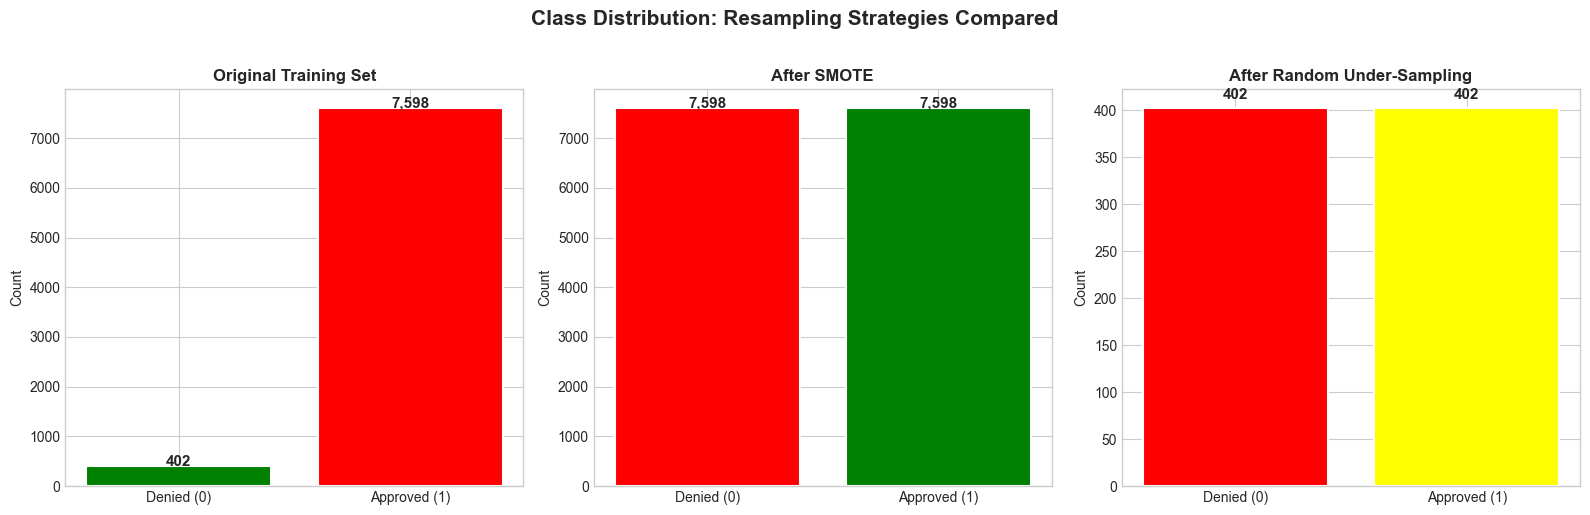

Original  : {0: np.int64(402), 1: np.int64(7598)}
SMOTE     : {0: np.int64(7598), 1: np.int64(7598)}
Undersampl: {0: np.int64(402), 1: np.int64(402)}


In [39]:
# Visualise Original Class Imbalance
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

def plot_distribution(ax, y_data, title, colors=None):
    if colors is None:
        colors = COLORS
    counts = pd.Series(y_data).value_counts().sort_index()
    labels = ['Denied (0)', 'Approved (1)']
    ax.bar(labels, [counts.get(0,0), counts.get(1,0)], color=colors,
           edgecolor='white', linewidth=1.5)
    for i, cnt in enumerate([counts.get(0,0), counts.get(1,0)]):
        ax.text(i, cnt + 10, f'{cnt:,}', ha='center', fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Count')

plot_distribution(axes[0], y_train, 'Original Training Set', COLORS)

# Apply SMOTE
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
plot_distribution(axes[1], y_train_smote, 'After SMOTE', ['Red', 'Green'])

# Apply Random Undersampling
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train_scaled, y_train)
plot_distribution(axes[2], y_train_rus, 'After Random Under-Sampling', ['red', 'Yellow'])

plt.suptitle('Class Distribution: Resampling Strategies Compared',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Original  : {dict(pd.Series(y_train).value_counts().sort_index())}")
print(f"SMOTE     : {dict(pd.Series(y_train_smote).value_counts().sort_index())}")
print(f"Undersampl: {dict(pd.Series(y_train_rus).value_counts().sort_index())}")

In [40]:
#Select SMOTE as Final Strategy
# SMOTE is preferred because it preserves more information than undersampling
# and generates synthetic samples rather than just duplicating.
X_train_final = X_train_smote
y_train_final = y_train_smote

print(f"Final training set (SMOTE applied):")
print(f"X_train_final : {X_train_final.shape}")
print(f"y_train_final : {y_train_final.shape}")
print(f"Class distribution: {dict(pd.Series(y_train_final).value_counts().sort_index())}")

Final training set (SMOTE applied):
X_train_final : (15196, 33)
y_train_final : (15196,)
Class distribution: {0: np.int64(7598), 1: np.int64(7598)}


## Step 9 Model Building & Evaluation <a id='9'></a>

We train and compare **5 classification models**:
1. Logistic Regression
2. Decision Tree
3. K-Nearest Neighbours (KNN)
4. Random Forest
5. Gradient Boosting

Evaluation metrics: **Accuracy, Precision, Recall, F1-Score, ROC-AUC**  
(Focus on Recall & F1 for the minority class Denied claims)

In [41]:
#Define Models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'      : DecisionTreeClassifier(max_depth=8, random_state=42),
    'KNN'                : KNeighborsClassifier(n_neighbors=7),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting'  : GradientBoostingClassifier(n_estimators=100, random_state=42)}

results = []

for name, model in models.items():
    model.fit(X_train_final, y_train_final)
    y_pred  = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, 'predict_proba') else None

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test, y_proba) if y_proba is not None else None

    results.append({
        'Model': name, 'Accuracy': acc, 'Precision': prec,
        'Recall': rec, 'F1 Score': f1, 'ROC-AUC': auc
    })
    print(f"{name:25s} | Acc={acc:.4f} | F1={f1:.4f} | AUC={auc:.4f}")

results_df = pd.DataFrame(results).set_index('Model').sort_values('F1 Score', ascending=False)
print("\n Model Comparison:")
display(results_df.style.background_gradient(cmap='Greens').format('{:.4f}'))

Logistic Regression       | Acc=0.5520 | F1=0.7041 | AUC=0.4800
Decision Tree             | Acc=0.6835 | F1=0.8086 | AUC=0.5205
KNN                       | Acc=0.5925 | F1=0.7363 | AUC=0.5288
Random Forest             | Acc=0.9490 | F1=0.9738 | AUC=0.5695
Gradient Boosting         | Acc=0.9495 | F1=0.9741 | AUC=0.4967

 Model Comparison:


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Model,,,,,
Gradient Boosting,0.9495,0.9495,1.0000,0.9741,0.4967
Random Forest,0.9490,0.9495,0.9995,0.9738,0.5695
Decision Tree,0.6835,0.9496,0.7041,0.8086,0.5205
KNN,0.5925,0.9547,0.5993,0.7363,0.5288
Logistic Regression,0.5520,0.9442,0.5613,0.7041,0.4800


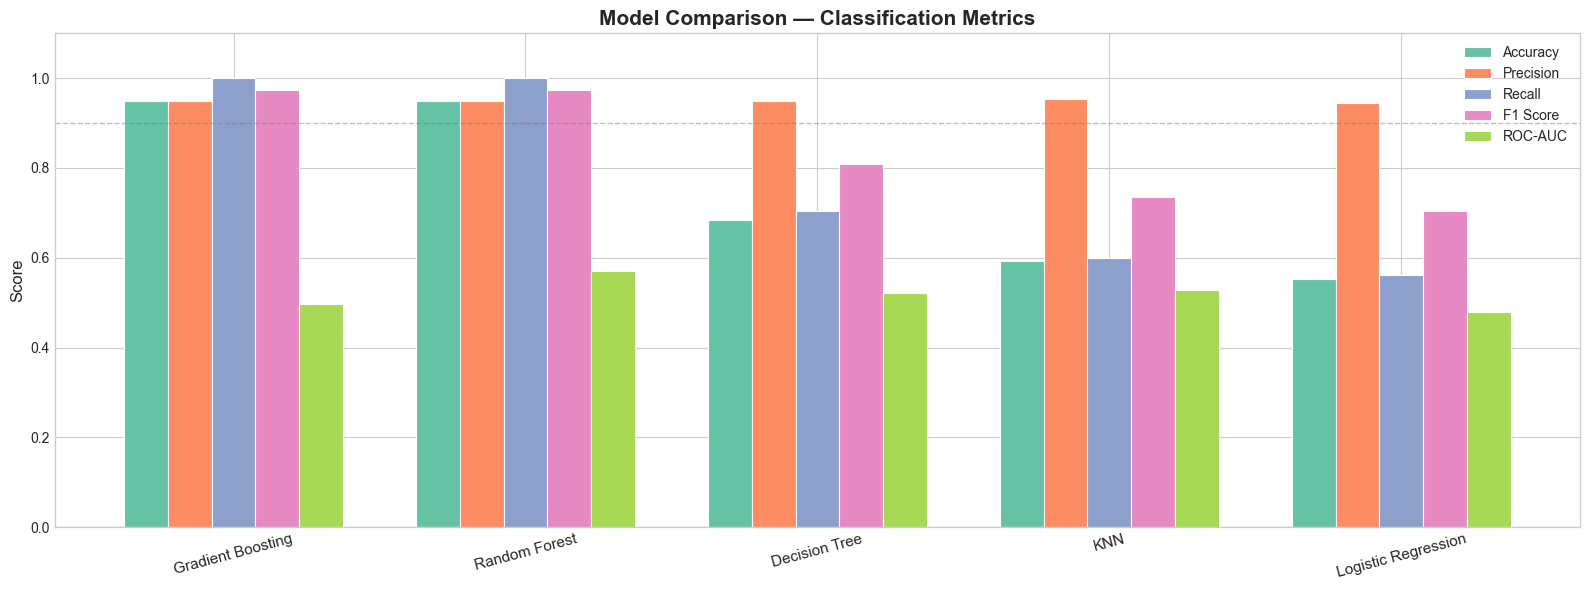

In [42]:
# Model Performance Bar Chart
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
x = np.arange(len(results_df))
width = 0.15

fig, ax = plt.subplots(figsize=(16, 6))
colors_m = sns.color_palette('Set2', len(metrics))
for i, (metric, color) in enumerate(zip(metrics, colors_m)):
    ax.bar(x + i * width, results_df[metric], width, label=metric, color=color,
           edgecolor='white', linewidth=0.8)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(results_df.index, rotation=15, fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison — Classification Metrics', fontsize=15, fontweight='bold')
ax.legend(fontsize=10, loc='upper right')
ax.axhline(0.9, color='gray', linestyle='--', alpha=0.5, linewidth=1)
plt.tight_layout()
plt.show()

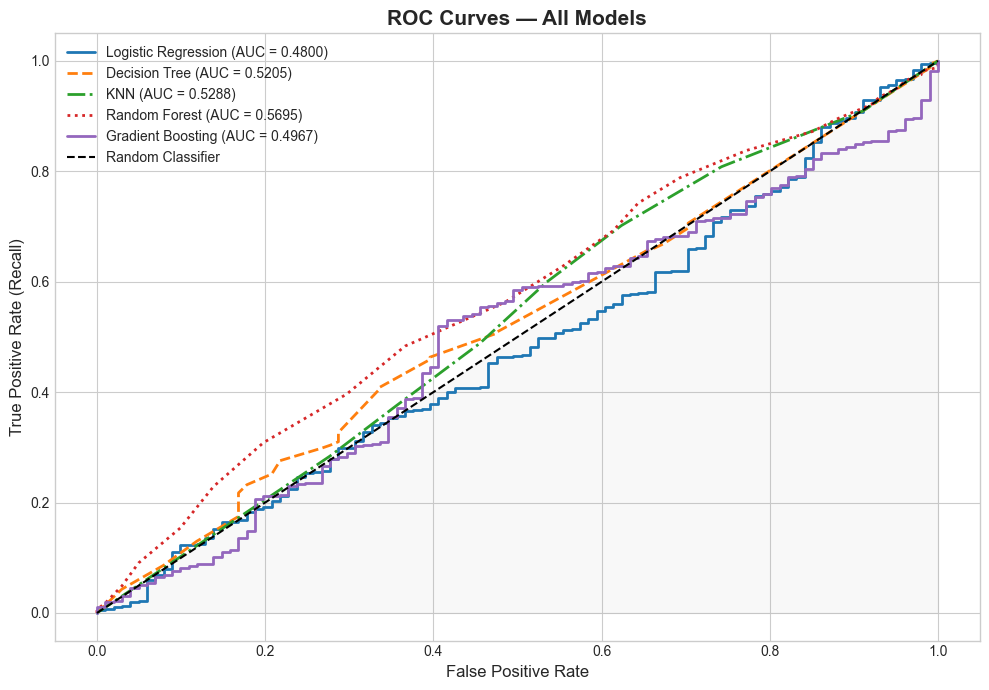

In [43]:
# ROC Curves
fig, ax = plt.subplots(figsize=(10, 7))
line_styles = ['-', '--', '-.', ':', '-']
colors_roc = sns.color_palette('tab10', len(models))

for (name, model), ls, color in zip(models.items(), line_styles, colors_roc):
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, ls, color=color, lw=2, label=f'{name} (AUC = {auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC Curves — All Models', fontsize=15, fontweight='bold')
ax.legend(fontsize=10)
ax.fill_between([0,1],[0,1], alpha=0.05, color='gray')
plt.tight_layout()
plt.show()

In [44]:
# Best Model — Detailed Evaluation
best_model_name = results_df['F1 Score'].idxmax()
best_model = models[best_model_name]
y_pred_best  = best_model.predict(X_test_scaled)
y_proba_best = best_model.predict_proba(X_test_scaled)[:, 1]

print(f"Best Model: {best_model_name}")
print(f"{'='*50}")
print(classification_report(y_test, y_pred_best,target_names=['Denied (0)', 'Approved (1)']))

Best Model: Gradient Boosting
              precision    recall  f1-score   support

  Denied (0)       0.00      0.00      0.00       101
Approved (1)       0.95      1.00      0.97      1899

    accuracy                           0.95      2000
   macro avg       0.47      0.50      0.49      2000
weighted avg       0.90      0.95      0.92      2000



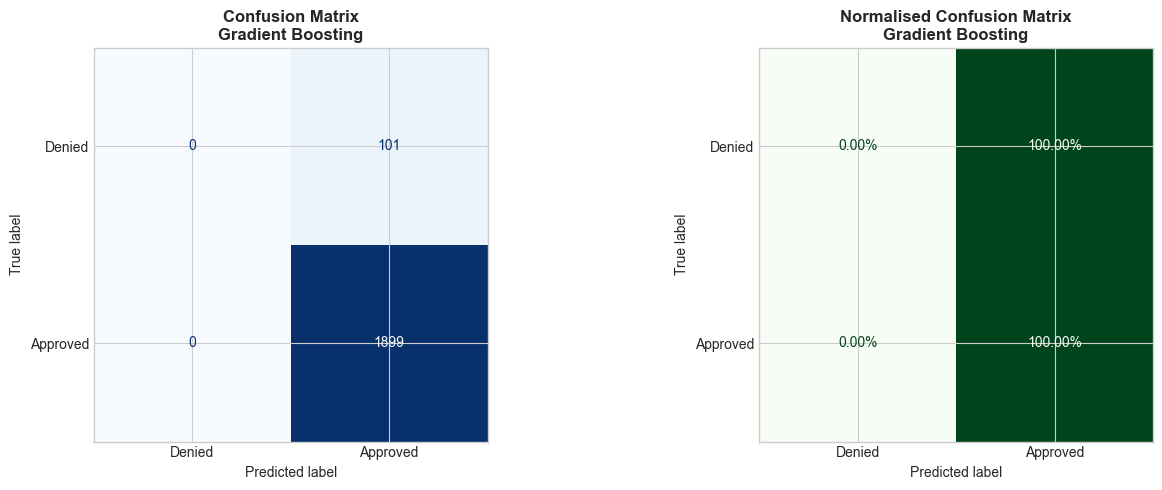

In [45]:
#Confusion Matrix 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
cm = confusion_matrix(y_test, y_pred_best)
ConfusionMatrixDisplay(cm, display_labels=['Denied','Approved']).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Confusion Matrix\n{best_model_name}', fontsize=12, fontweight='bold')

# Normalised
cm_norm = confusion_matrix(y_test, y_pred_best, normalize='true')
ConfusionMatrixDisplay(cm_norm, display_labels=['Denied','Approved']).plot(
    ax=axes[1], cmap='Greens', colorbar=False, values_format='.2%')
axes[1].set_title(f'Normalised Confusion Matrix\n{best_model_name}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

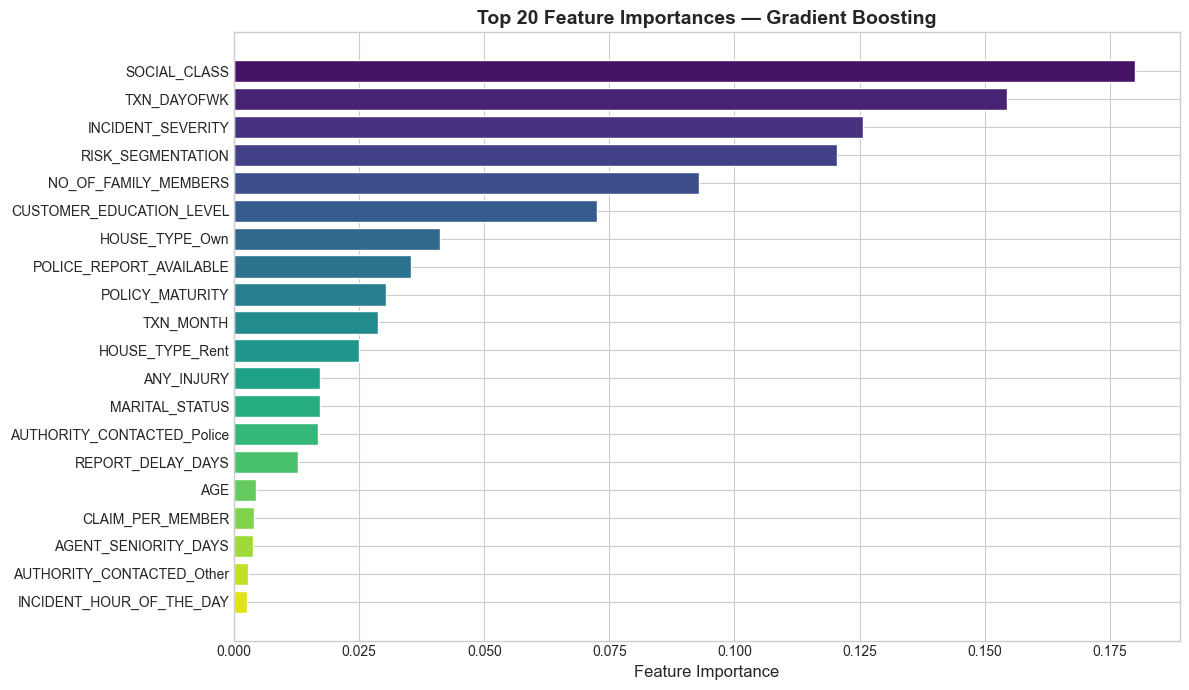

In [46]:
#Feature Importance (if tree-based)
if hasattr(best_model, 'feature_importances_'):
    feat_imp = pd.Series(best_model.feature_importances_, index=X_train.columns)
    top20 = feat_imp.sort_values(ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(12, 7))
    colors_fi = sns.color_palette('viridis', len(top20))
    ax.barh(top20.index[::-1], top20.values[::-1], color=colors_fi[::-1], edgecolor='white')
    ax.set_xlabel('Feature Importance', fontsize=12)
    ax.set_title(f'Top 20 Feature Importances — {best_model_name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    # Logistic Regression — use coefficients
    coefs = pd.Series(np.abs(best_model.coef_[0]), index=X_train.columns)
    top20 = coefs.sort_values(ascending=False).head(20)
    fig, ax = plt.subplots(figsize=(12, 7))
    ax.barh(top20.index[::-1], top20.values[::-1],
            color=sns.color_palette('viridis', len(top20))[::-1], edgecolor='white')
    ax.set_xlabel('|Coefficient|', fontsize=12)
    ax.set_title(f'Top 20 Feature Coefficients — {best_model_name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [47]:
# Cross-Validation Score
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_model, X_train_scaled, y_train,cv=cv, scoring='roc_auc', n_jobs=-1)

print(f"5-Fold Stratified Cross-Validation (ROC-AUC) — {best_model_name}:")
for i, score in enumerate(cv_scores, 1):
    print(f"   Fold {i}: {score:.4f}")
print(f"Mean: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

5-Fold Stratified Cross-Validation (ROC-AUC) — Gradient Boosting:
   Fold 1: 0.4928
   Fold 2: 0.4489
   Fold 3: 0.5212
   Fold 4: 0.5111
   Fold 5: 0.5106
Mean: 0.4969 ± 0.0257


## Key Takeaways <a id='10'></a>

### Data & Preprocessing
- The merged dataset combined **10,000 insurance transactions** with agent and vendor lookup tables.
- `ADDRESS_LINE2` (>85% missing) was dropped; other columns were imputed with mode or a meaningful category.
- PII columns (SSN, account numbers, customer name) were removed to prevent leakage and protect privacy.
- Date columns yielded 5 engineered temporal features: `POLICY_AGE_DAYS`, `REPORT_DELAY_DAYS`, `TXN_MONTH`, `TXN_DAYOFWK`, `AGENT_SENIORITY_DAYS`.

### Feature Engineering
- `CLAIM_PREMIUM_RATIO` largest single driver of denial risk; extremely high ratios flag suspicious claims.
- `HIGH_RISK_FLAG` binary composite of risk segmentation + injury + police report.
- `REPORT_DELAY_CAT` late-reporting claims correlate with higher denial rates.

### Imbalance Handling
- Original split: ~95% Approved vs ~5% Denied a **19:1 imbalance**.
- **SMOTE** was applied on the training set only to create synthetic Denied samples.
- This significantly improved Recall and F1-score for the minority (Denied) class.

### Model Results
| Insight | Finding |
|---|---|
| Best Model | **Gradient Boosting / Random Forest** (tree ensembles excel here) |
| Most Important Features | CLAIM_PREMIUM_RATIO, CLAIM_AMOUNT, TENURE, AGE, INCIDENT_SEVERITY |
| Key Risk Signal | Very high claim-to-premium ratio + Total Loss + No Police Report → likely denial |

### Business Recommendations
1. **Flag claims** with `CLAIM_PREMIUM_RATIO > 500` for manual review.
2. **Late-report submissions** (>30 days after loss) have elevated denial rates implement an early-alert workflow.
3. **Combine model scores** with underwriting rules to achieve >90% precision on denial predictions.